# Mapas de Flujo de Calor
***
created: 07/05/2026             updated: 

En este código se crea un programa que calcula el flujo de calor neto por cuencas. Para ello se usan los archivos que están en ./Data/Heat_vars/ y se realiza el siguiente calculo por cuencas:

$Q_i = \frac{1}{a(4000)}\int_{4000}^{bottom}\rho C_p (\frac{d\theta}{dt})adz$

Donde $a$ representa la superficie de la cuenca a la presión dada, $\rho$ es la densidad del agua para esa presión y $C_p$ es la capacidad calorífica a presión constante. Para realizar el cálculo se usan métodos númericos de aproximación. En concreto se hace una sumatoria sobre la presión de 20 en 20 dbar. En primer lugar se calculará el flujo total de todas las cuencas, y luego se representará este flujo de calor por cuencas.

In [1]:
# Packages for calculations and data manipulation
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import median_abs_deviation
from surface import surface

# Packages for representation
import matplotlib.pyplot as plt
import cartopy
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm

# For progress bar
from tqdm import tqdm

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Características previas y apertura de archivos

In [2]:
resolution = '25'
dates = '1990_2010'
pressure_max = None
pressure_min = '4000'
pressure_code = pressure_min[0] + 'k' # Poner + pressure_max[0] si hace falta
robust = True
median = False

if robust:
    file_name = f'Heat_vars_{dates}_{resolution}_{pressure_code}_robust'
    fig_name = f'{dates}_{resolution}_{pressure_code}_robust'
else :
    file_name = f'Heat_vars_{dates}_{resolution}_{pressure_code}'
    fig_name = f'{dates}_{resolution}'

In [3]:
ds = xr.open_dataset(f'./Data/Heat_vars/{file_name}.nc')
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (latitude: 556, longitude: 1309, pressure: 125)
Coordinates:
  * latitude   (latitude) float64 4kB -76.75 -76.5 -76.0 ... 62.75 63.0 63.25
  * longitude  (longitude) float64 10kB -180.0 -179.8 -179.5 ... 179.8 180.0
    mask       (latitude, longitude) float64 6MB ...
    basin      (latitude, longitude) <U18 52MB ...
    batimetry  (latitude, longitude) float64 6MB ...
    surface    (latitude, longitude) float64 6MB ...
  * pressure   (pressure) int64 1kB 4000 4020 4040 4060 ... 6420 6440 6460 6480
Data variables:
    tendency   (latitude, longitude, pressure) float64 728MB ...
    density    (latitude, longitude, pressure) float64 728MB ...
    Cp         (latitude, longitude, pressure) float64 728MB ...
Attributes:
    description:  Dataset of temperature tendencies by pressure levels betwee...

### Cálculo de flujo por cuencas

In [4]:
# Function which given a dataframe and a level, calculate the heat flux
def basin_heat_flux(ds, level_step = 20):
    # Calculate the mean of all the vars by levels
    ds_mean = ds.mean(dim = ['latitude', 'longitude'])

    # If the basin has no valid data, return NaN
    if np.all(np.isnan(ds_mean.tendency.values)):
        return np.nan

    # Return Nan if there is not any tendency data
    if np.all(np.isnan(ds_mean.tendency.values)):
        return np.nan
    
    # Create the variable q (without normalization)
    q = 0

    # Iterate for every press level
    pressure = ds_mean.pressure.values
    tendency_matrix = ds_mean.tendency.values
    density_matrix = ds_mean.density.values
    cp_matrix = ds_mean.Cp.values

    for i, level in enumerate(pressure):
        if np.isnan(tendency_matrix[i]):
            continue
        else:
            surf = surface(ds, level)
            cp = cp_matrix[i]
            density = density_matrix[i]
            tendency = tendency_matrix[i]
            q += surf * level_step * density * tendency * cp
    
    # Extract the basin areea at 4000 dbar and normalize by this value
    a = surface(ds, 4000)
    Q = q/a

    segundos_por_siglo = 100 * 365.25 * 24 * 3600
    Q = Q / segundos_por_siglo

    # Return the value
    return Q

In [5]:
# Importing the unique values of the mask
cuencas = np.unique(ds.mask.values)

basin_idx = [] # Number of the basin
basin_Q = [] # Heat Flux of the basin

# Iterate for every 'cuenca'
for cuenca in tqdm(cuencas):
    if np.isnan(cuenca): # Skip is cuenca is Nan
        continue

    else:
        ds_basin = ds.where(ds.mask == cuenca)
        Q = basin_heat_flux(ds_basin)

        # Import values to the list
        basin_idx.append(cuenca)
        basin_Q.append(Q)        

  0%|          | 0/29 [00:00<?, ?it/s]

100%|██████████| 29/29 [01:23<00:00,  2.86s/it]


Creamos el dataset con el flujo

In [6]:
# Load the values of lat, lon and mask
latitudes = ds.latitude.values
longitudes = ds.longitude.values
mask = ds.mask.values

# Creating empty matrix
heat_flux = np.full((len(latitudes), len(longitudes)), np.nan)

# Iterate for each basin
for k, basin in enumerate(basin_idx):
    heat_flux = np.where(mask == basin, basin_Q[k], heat_flux)

In [7]:
# Adding the variable to the dataset
ds['heat_flux'] = (('latitude', 'longitude'), heat_flux)
ds = ds.set_coords(['heat_flux'])

In [8]:
# Save the dataset for future opening
if robust:
    ds.to_netcdf(f'./Data/Heat_flux/Heat_flux_{dates}_{resolution}_{pressure_code}_robust.nc')
else:
    ds.to_netcdf(f'./Data/Heat_flux/Heat_flux_{dates}_{resolution}_{pressure_code}.nc')

In [ ]:
# Open dataset if you need
if robust:
    ds = xr.open_dataset(f'./Data/Heat_flux/Heat_flux_{dates}_{resolution}_{pressure_code}_robust.nc')
else:
    ds = xr.open_dataset(f'./Data/Heat_flux/Heat_flux_{dates}_{resolution}_{pressure_code}.nc')

### Mapa de flujos de Calor

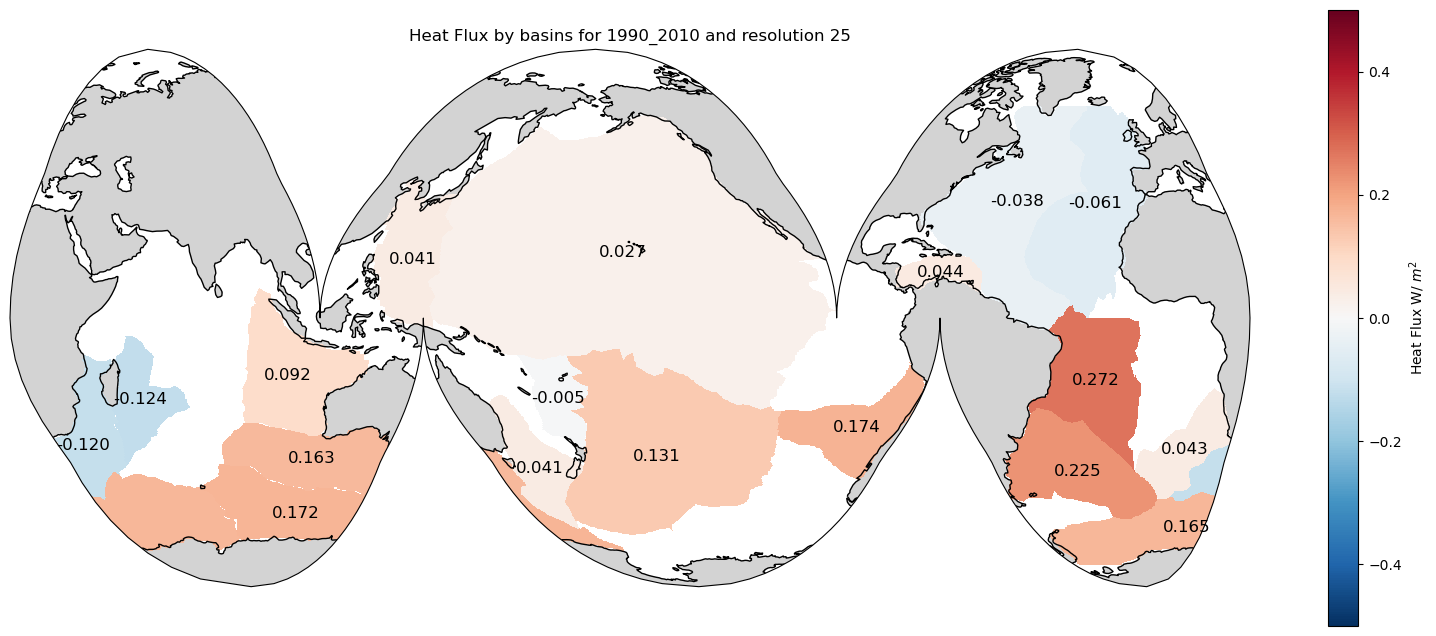

In [9]:
# Creating figure
fig, ax = plt.subplots(figsize=(20,10),
    subplot_kw={'projection': ccrs.InterruptedGoodeHomolosine(central_longitude=-160,emphasis='ocean')})

# Ploting mean
means = ds.heat_flux.plot(ax = ax, cmap = "RdBu_r", transform = ccrs.PlateCarree(),  add_colorbar = False, vmin = -0.5, vmax = 0.5)

# Colorbar
fig.colorbar(mappable = means, shrink = 0.8, label = r'Heat Flux W/ $m^2$')

# Plotting features
ax.set_global()
ax.coastlines(resolution='110m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Title
ax.set_title(f'Heat Flux by basins for {dates} and resolution {resolution}')

# Plotting text
for k, basin in enumerate(basin_idx):
    if not np.isnan(basin_Q[k]):
        latitude = ds.latitude.where(ds.mask == basin).values
        longitude = ds.longitude.where(ds.mask == basin).values

        # Normal mean for latitude
        mean_lat = np.nanmean(latitude)

        # Ciruclar mean for longitude
        lon_rad = np.radians(longitude)
        mean_lon = np.degrees(np.arctan2(np.nanmean(np.sin(lon_rad)), np.nanmean(np.cos(lon_rad))))

        ax.text(mean_lon,mean_lat, rf'{basin_Q[k]:.3f}', transform=ccrs.PlateCarree(),fontsize=12,ha='center',va='center',bbox=dict(facecolor='white', alpha=0,edgecolor='none'))
    else:
        continue

# Save plot
plt.savefig(f'./plots/Mapas_Heat_Flux/Heat_flux_{fig_name}.png')

### Cerrar todo

In [28]:
ds.close()
plt.close('all')